# Rearrangement Testing

In [2]:
from pytweezer.experiment.motmaster_client import MotMasterClient
from pytweezer.drivers.imagemX2 import ImagEMX2Camera
from pytweezer.drivers.slm import SLM
from pytweezer.drivers.thorcam import ThorCamera
from pytweezer.experiment.experiment_parameter_manager import ExpParameterManager
import pytweezer.phasemask as pm
import pytweezer.analysis as an
import numpy as np
import matplotlib.pyplot as plt

ExpParams = ExpParameterManager()

In [3]:
exp : MotMasterClient = MotMasterClient()
motcam : ThorCamera = ThorCamera(id="motcam")
slm : SLM = SLM()
hamcam : ImagEMX2Camera = ImagEMX2Camera()

Rb MotMasterClient initialised.
Thorlabs TLCamera - motcam - initialised.
SLM 1 initialised: 1024x1024 @ 8-bit, serial 7752, 40.200 degC
SLM 1 loaded LUT "C:\Program Files\Meadowlark Optics\Blink Plus\LUT Files\slm40_at852.LUT"
ImagEM X2 camera initialised.


In [4]:
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)
exp.set_motmaster_experiment("RbTweezerBasic2026_2")

motcam.set_trigger_source("bulb")

hamcam.set_trigger_source("ext")
hamcam.set_external_exposure_mode()
hamcam.enable_em_gain(True)
hamcam.enable_direct_em_gain(True)
hamcam.set_sensitivity(600)
hamcam.timeout = 60*20
X0, Y0, WIDTH, HEIGHT = 110, 220, 256, 256
hamcam.set_roi(X0, WIDTH, Y0, HEIGHT)

## MOT Check

MOT detected at (x, y): (932, 562)


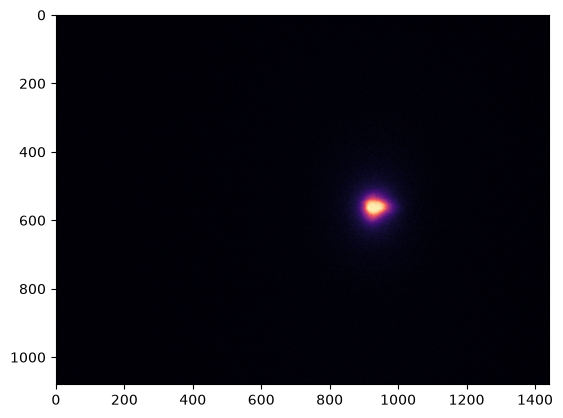

In [15]:
img_it = 10
bg_it = 2

exp.set_iterations(bg_it)
motcam.setup_acquisition(nframes=bg_it)
motcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tDelay2": 1, 
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 35000})
imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

exp.set_iterations(img_it)
motcam.setup_acquisition(nframes=img_it)
motcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, 
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 35000})
imgs = motcam.acquire_n_frames(nframes=img_it)
img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)

plt.imshow(img_mean, cmap='magma', vmin=0)

try:
    gaussian_params = an.fit_gaussian(img_mean)
    centre_x, centre_y = int(gaussian_params["x0"]), int(gaussian_params["y0"])
    print(f"MOT detected at (x, y): ({centre_x}, {centre_y})")
except Exception as e:
    print(f"Could not detect MOT: {e}")

## Generate Tweezer Array

In [5]:
dx, dy = 8.0, 12.0
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40+dx, -8+dy),
                 zernike_coeff_dict={5:1.195, 6:0.725, 7:0.970, 8:0.478, 9:-1.091, 10:0.303, 11:0.021, 12:0.072, 13:0.049})

gauss2d = lambda x, y, A, x0, y0, sx, sy, offset: (A * np.exp(-(((x - x0) ** 2) / (2 * sx ** 2) + ((y - y0) ** 2) / (2 * sy ** 2)))) + offset
A, x0, y0, sx, sy, offset = [-2.14197604e+03, -1.11443850e+01 - dx, 2.09919600e+00 - dy, 2.95002910e+03, 2.64281503e+03, 2.14239505e+03]

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um


In [6]:
W1 = np.ones((10,10))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W1, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W1 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms1 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array1, terms1, _ = PM.superposition_optimization(terms1, max_iter=2000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 10x10
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 1.52e-05 | Uniformity: 55.84% | Min/Max ratio: 0.049
Iteration 010 | Mean-Squared Error: 2.08e-07 | Uniformity: 83.41% | Min/Max ratio: 0.527
Iteration 020 | Mean-Squared Error: 6.59e-08 | Uniformity: 82.78% | Min/Max ratio: 0.504
Iteration 030 | Mean-Squared Error: 9.39e-09 | Uniformity: 83.52% | Min/Max ratio: 0.529
Iteration 040 | Mean-Squared Error: 4.46e-09 | Uniformity: 83.57% | Min/Max ratio: 0.529
Iteration 050 | Mean-Squared Error: 5.64e-09 | Uniformity: 83.56% | Min/Max ratio: 0.532
Iteration 060 | Mean-Squared Error: 2.44e-09 | Uniformity: 83.56% | Min/Max ratio: 0.530
Iteration 070 | Mean-Squared Error: 3.80e-09 | Uniformity: 83.47% | Min/Max ratio: 0.524
Iteration 080 | Mean-Squared Error: 1.90e-09 | Uniformity: 83.48% | Min/Max ratio: 0.526
Iteration 090 | Mean-Squared Error: 5.63e-10 | Uniformity: 83.54% | Min/Max ratio: 0.529
Itera

In [7]:
W2 = np.ones((6,6))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W2, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W2 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms2 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array2, terms2, _ = PM.superposition_optimization(terms2, max_iter=5000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 6x6
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 1.30e-04 | Uniformity: 57.26% | Min/Max ratio: 0.192
Iteration 010 | Mean-Squared Error: 9.78e-07 | Uniformity: 90.28% | Min/Max ratio: 0.680
Iteration 020 | Mean-Squared Error: 9.82e-08 | Uniformity: 89.83% | Min/Max ratio: 0.675
Iteration 030 | Mean-Squared Error: 1.45e-08 | Uniformity: 89.99% | Min/Max ratio: 0.685
Iteration 040 | Mean-Squared Error: 1.25e-09 | Uniformity: 90.08% | Min/Max ratio: 0.688
Iteration 050 | Mean-Squared Error: 1.00e-10 | Uniformity: 90.10% | Min/Max ratio: 0.688
Iteration 060 | Mean-Squared Error: 1.18e-11 | Uniformity: 90.10% | Min/Max ratio: 0.688
Iteration 070 | Mean-Squared Error: 2.82e-12 | Uniformity: 90.10% | Min/Max ratio: 0.688
Iteration 080 | Mean-Squared Error: 1.45e-12 | Uniformity: 90.11% | Min/Max ratio: 0.688
Iteration 090 | Mean-Squared Error: 1.07e-12 | Uniformity: 90.11% | Min/Max ratio: 0.688
Iterati

In [8]:
pm_composite = PM.superimpose([pm_array1, PM.fresnel, PM.blaze, PM.zernike])
pm_composite_uint8 = PM.transform_phase_8bit(pm_composite).get()
slm.update_mask(pm_composite_uint8)

## Baseline - Initial Array

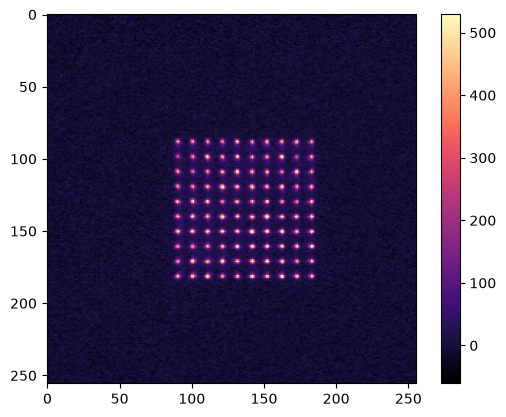

In [9]:
# Experiment and camera setup
n_iterations = 100
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({
    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
    "BackgroundDrop": 1})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]
img_average = an.tweezer_show_bg_subtracted(imgs1, imgs2, cmap='magma', show=True, vmaxfactor=0.6, show_grid=True)

Looking for trap sites...
10x10 array detected.


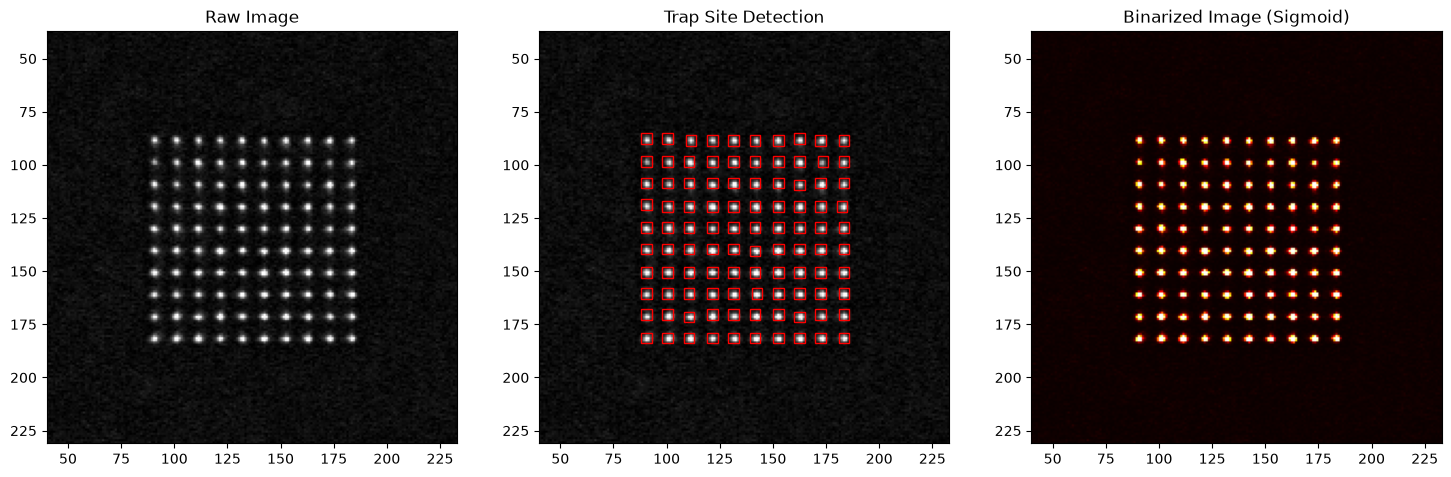

Trap (0, 0) Loading Probability : 54.00 %
Trap (0, 1) Loading Probability : 53.00 %
Trap (0, 2) Loading Probability : 48.00 %
Trap (0, 3) Loading Probability : 53.00 %
Trap (0, 4) Loading Probability : 55.00 %
Trap (0, 5) Loading Probability : 51.00 %
Trap (0, 6) Loading Probability : 62.00 %
Trap (0, 7) Loading Probability : 57.00 %
Trap (0, 8) Loading Probability : 59.00 %
Trap (0, 9) Loading Probability : 54.00 %
Trap (1, 0) Loading Probability : 43.00 %
Trap (1, 1) Loading Probability : 39.00 %
Trap (1, 2) Loading Probability : 61.00 %
Trap (1, 3) Loading Probability : 47.00 %
Trap (1, 4) Loading Probability : 51.00 %
Trap (1, 5) Loading Probability : 49.00 %
Trap (1, 6) Loading Probability : 54.00 %
Trap (1, 7) Loading Probability : 56.00 %
Trap (1, 8) Loading Probability : 40.00 %
Trap (1, 9) Loading Probability : 46.00 %
Trap (2, 0) Loading Probability : 52.00 %
Trap (2, 1) Loading Probability : 43.00 %
Trap (2, 2) Loading Probability : 46.00 %
Trap (2, 3) Loading Probability : 

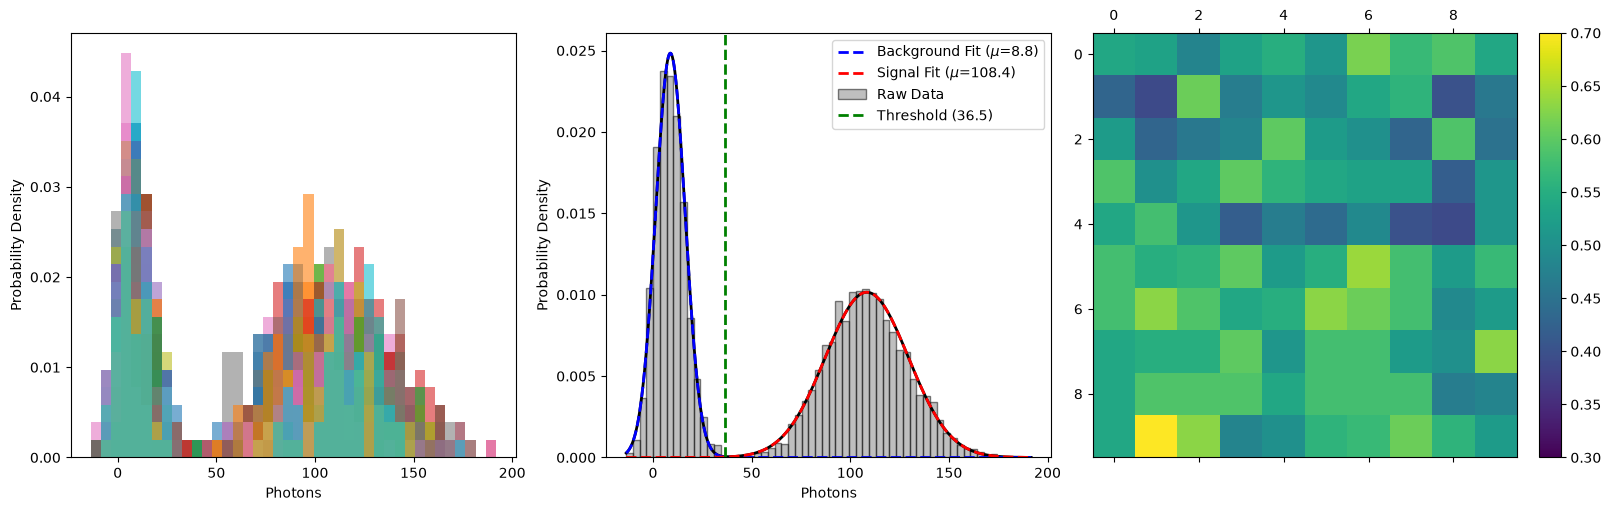

In [10]:
array_shape_1 = [10, 10]
window = 5
feature_size = 10

filtered_img_average = an.morphological_tophat_high_pass(img_average, feature_size=feature_size)
grid_positions_1, detection_threshold = an.detect_trap_sites(filtered_img_average, array_shape_1, detection_step=200)
an.visualize_results(filtered_img_average, grid_positions_1, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)
imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_1, array_shape_1, threshold_detection=True, window_size=window, binning=60)

## Fast Shim Coil Optimisation

In [19]:
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from skopt import Optimizer

In [24]:
# --- 1. Define the Experimental Search Space ---
dimensions = [  
    Real(name='tMOTShimXccValue', low=0.0, high=10.0),
    Real(name='tMOTShimYccValue', low=-5.0, high=5.0),
    Real(name='tMOTShimZccValue', low=-1.0, high=1.0)
]

# Experiment and camera setup
n_iterations = 20
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)

@use_named_args(dimensions=dimensions)
def tweezer_exp_objective(tMOTShimXccValue, tMOTShimYccValue, tMOTShimZccValue):
    hamcam.start_acquisition()
    exp.start_motmaster_experiment({
            "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
            "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
            "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
            "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
            "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
            "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
            "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
            "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
            "tMOTShimXccValue": tMOTShimXccValue, "tMOTShimYccValue": tMOTShimYccValue, "tMOTShimZccValue": tMOTShimZccValue,
            "tMOTLoadingDuration": 10000, "PatternLength": 40000})

    imgs = hamcam.acquire_n_frames(n_iterations * 2)
    imgs1, imgs2 = imgs[::2], imgs[1::2]
    imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]

    _, loading_probabilities, _, fidelity = an.get_array_loading_statistics(imgs_filtered_1, grid_positions_1, array_shape_1, threshold_detection=False, threshold=40.0, window_size=window, binning=60, verbose=False, show_histogram=False)
    mean_loading_probability = np.mean(loading_probabilities)
    measured_loss = 1.0 - mean_loading_probability

    print(f"Parameters: tMOTShimXccValue = {tMOTShimXccValue:.2f}, tMOTShimYccValue = {tMOTShimYccValue:.2f}, tMOTShimZccValue = {tMOTShimZccValue:.2f}  |  Mean Loading Probability = {mean_loading_probability:.4f}")
    return measured_loss

In [25]:
print("Starting Bayesian Optimization with dynamic exploration...")

n_calls = 50
n_initial_points = 10
xi_start = 0.100
xi_end = 0.001

opt = Optimizer(
    dimensions=dimensions,
    n_initial_points=n_initial_points,
    acq_func='EI',
    random_state=50
)

# Custom optimization loop
for i in range(n_calls):
    current_xi = xi_start - (xi_start - xi_end) * (i / (n_calls - 1))
    opt.acq_func_kwargs = {'xi': current_xi}
    suggested_params = opt.ask()
    loss = tweezer_exp_objective(suggested_params)
    result = opt.tell(suggested_params, loss)
    print(f"Iteration {i+1}/{n_calls} (xi = {current_xi:.4f})")
    print(f"  Current score: {(1-loss):.4f}")
    print(f"  Best score: {(1-result.fun):.4f}\n")

# --- 4. Analyze the Results ---
print("\n" + "="*40)
print("Optimization Complete!")
print("="*40)

high_score = 1 - result.fun
best_params = result.x

print(f"Best Parameters Found:")
for dim, value in zip(dimensions, best_params):
    print(f"  {dim.name}: {value:.4f}")

Starting Bayesian Optimization with dynamic exploration...


C:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:374: RuntimeWarning: divide by zero encountered in scalar divide
  fidelity = norm.cdf((threshold - mu_sig) / np.sqrt(var_sig)) + (1 - norm.cdf((threshold - mu_bg) / np.sqrt(var_bg)))


Parameters: tMOTShimXccValue = 1.29, tMOTShimYccValue = -4.26, tMOTShimZccValue = 0.22  |  Mean Loading Probability = 0.0005
Iteration 1/50 (xi = 0.1000)
  Current score: 0.0005
  Best score: 0.0005

Parameters: tMOTShimXccValue = 0.21, tMOTShimYccValue = -3.48, tMOTShimZccValue = 0.91  |  Mean Loading Probability = 0.0005
Iteration 2/50 (xi = 0.0980)
  Current score: 0.0005
  Best score: 0.0005

Parameters: tMOTShimXccValue = 8.05, tMOTShimYccValue = -2.56, tMOTShimZccValue = -0.35  |  Mean Loading Probability = 0.0095
Iteration 3/50 (xi = 0.0960)
  Current score: 0.0095
  Best score: 0.0095

Parameters: tMOTShimXccValue = 4.39, tMOTShimYccValue = -3.65, tMOTShimZccValue = 0.19  |  Mean Loading Probability = 0.0010
Iteration 4/50 (xi = 0.0939)
  Current score: 0.0010
  Best score: 0.0095

Parameters: tMOTShimXccValue = 9.78, tMOTShimYccValue = -4.11, tMOTShimZccValue = -0.41  |  Mean Loading Probability = 0.0045
Iteration 5/50 (xi = 0.0919)
  Current score: 0.0045
  Best score: 0.0095

C:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:371: RuntimeWarning: Mean of empty slice
  mu_sig = tot_photon_array[tot_photon_array >= threshold].mean()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:373: RuntimeWarning: Degrees of freedom <= 0 for slice
  var_sig = tot_photon_array[tot_photon_array >= threshold].var()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = 

Parameters: tMOTShimXccValue = 9.67, tMOTShimYccValue = 4.78, tMOTShimZccValue = 1.00  |  Mean Loading Probability = 0.0000
Iteration 12/50 (xi = 0.0778)
  Current score: 0.0000
  Best score: 0.0605

Parameters: tMOTShimXccValue = 9.73, tMOTShimYccValue = 4.50, tMOTShimZccValue = -0.99  |  Mean Loading Probability = 0.0010
Iteration 13/50 (xi = 0.0758)
  Current score: 0.0010
  Best score: 0.0605

Parameters: tMOTShimXccValue = 0.08, tMOTShimYccValue = -4.54, tMOTShimZccValue = -0.25  |  Mean Loading Probability = 0.0580
Iteration 14/50 (xi = 0.0737)
  Current score: 0.0580
  Best score: 0.0605



...

Parameters: tMOTShimXccValue = 2.66, tMOTShimYccValue = -0.83, tMOTShimZccValue = 0.99  |  Mean Loading Probability = 0.0005
Iteration 26/50 (xi = 0.0495)
  Current score: 0.0005
  Best score: 0.2360

Parameters: tMOTShimXccValue = 3.43, tMOTShimYccValue = 3.52, tMOTShimZccValue = -1.00  |  Mean Loading Probability = 0.0050
Iteration 27/50 (xi = 0.0475)
  Current score: 0.0050
  Best score: 0.2360

Parameters: tMOTShimXccValue = 0.00, tMOTShimYccValue = -5.00, tMOTShimZccValue = -1.00  |  Mean Loading Probability = 0.1815
Iteration 28/50 (xi = 0.0454)
  Current score: 0.1815
  Best score: 0.2360

Parameters: tMOTShimXccValue = 0.79, tMOTShimYccValue = -2.99, tMOTShimZccValue = -1.00  |  Mean Loading Probability = 0.0840
Iteration 29/50 (xi = 0.0434)
  Current score: 0.0840
  Best score: 0.2360



C:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:371: RuntimeWarning: Mean of empty slice
  mu_sig = tot_photon_array[tot_photon_array >= threshold].mean()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:373: RuntimeWarning: Degrees of freedom <= 0 for slice
  var_sig = tot_photon_array[tot_photon_array >= threshold].var()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = 

Parameters: tMOTShimXccValue = 0.32, tMOTShimYccValue = 4.95, tMOTShimZccValue = 0.97  |  Mean Loading Probability = 0.0000
Iteration 30/50 (xi = 0.0414)
  Current score: 0.0000
  Best score: 0.2360



C:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:374: RuntimeWarning: divide by zero encountered in scalar divide
  fidelity = norm.cdf((threshold - mu_sig) / np.sqrt(var_sig)) + (1 - norm.cdf((threshold - mu_bg) / np.sqrt(var_bg)))


Parameters: tMOTShimXccValue = 9.88, tMOTShimYccValue = 4.69, tMOTShimZccValue = 0.08  |  Mean Loading Probability = 0.0005
Iteration 31/50 (xi = 0.0394)
  Current score: 0.0005
  Best score: 0.2360

Parameters: tMOTShimXccValue = 0.15, tMOTShimYccValue = -4.80, tMOTShimZccValue = -0.87  |  Mean Loading Probability = 0.2615
Iteration 32/50 (xi = 0.0374)
  Current score: 0.2615
  Best score: 0.2615

Parameters: tMOTShimXccValue = 0.17, tMOTShimYccValue = -4.97, tMOTShimZccValue = -0.98  |  Mean Loading Probability = 0.1820
Iteration 33/50 (xi = 0.0353)
  Current score: 0.1820
  Best score: 0.2615

Parameters: tMOTShimXccValue = 0.16, tMOTShimYccValue = -4.98, tMOTShimZccValue = -0.67  |  Mean Loading Probability = 0.2595
Iteration 34/50 (xi = 0.0333)
  Current score: 0.2595
  Best score: 0.2615

Parameters: tMOTShimXccValue = 0.01, tMOTShimYccValue = -4.48, tMOTShimZccValue = -0.66  |  Mean Loading Probability = 0.2760
Iteration 35/50 (xi = 0.0313)
  Current score: 0.2760
  Best score: 

In [26]:
ExpParams.set_parameter("tMOTShimXccValue", best_params[0])
ExpParams.set_parameter("tMOTShimYccValue", best_params[1])
ExpParams.set_parameter("tMOTShimZccValue", best_params[2])
ExpParams.save_parameters()

Parameter 'tMOTShimXccValue' set to 0.0.
Parameter 'tMOTShimYccValue' set to -2.026359047273954.
Parameter 'tMOTShimZccValue' set to -0.5386689646897473.
Parameters saved.


## Rearrangement Init

In [12]:
threshold_count = an.convert_photons_to_counts(threshold_1)
threshold_count

np.float64(4663.504183532503)

In [14]:
import asyncio
from pytweezer.coordinators.rearrangement import Rearrangement
from pytweezer.drivers.arduino import ArduinoPulser

coordinator = Rearrangement({"camera": hamcam, "slm": slm}, {})

data1, array_shape1 = np.stack(terms1[:4]), terms1[4]
data2, array_shape2 = np.stack(terms2[:4]), terms2[4]
await asyncio.to_thread(
    coordinator.initialise,
    data1, data2, array_shape1, array_shape2,
    d0=1.0, fps=1/(1e-6), threshold=threshold_count,
    grid_positions=grid_positions_1, roi=[X0, Y0, WIDTH, HEIGHT], profile="linear"
)

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um
Phasemask generator initialised.
Camera configured for rearrangement (roi=%s). [110, 220, 256, 256]
Rearrangement node initialised.


## Rearrangement Exp

In [15]:
import time

# Experiment and camera setup
n_iterations = 1
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)

{'ok': True,
 'command': 'interface_method',
 'method': 'set_run_until_stopped',
 'state': 'accepted'}

In [ ]:
N_iterations = 200  # adjust before running
imgs_software = []
err_indices = []
timings_log = []

for it in range(N_iterations):
    print(f"Running experiment iteration {it+1} / {N_iterations}")
    rearrangement_task = asyncio.create_task(asyncio.to_thread(coordinator.arm_rearrangement))

    time.sleep(0.1)
    exp.start_motmaster_experiment({
                "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
                "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
                "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
                "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
                "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
                "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
                "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
                "BackgroundDrop": 0})
    img0, img1, timings = await rearrangement_task
    print("Images acquired from rearrangement node.")

    if img1.sum() == 0:
        print(f"Empty image received at iteration {it+1}. Discarding...")
        err_indices.append(it)
    else:
        imgs_software.append([img0, img1])
    timings_log.append(timings)

mean_rearrangement_time_ms = np.mean([t['total_rearrangement_ms'] for t in timings_log])
mean_calc_upload_time_ms = np.mean([t['calculation_and_upload_ms'] for t in timings_log])
mean_nframes = np.mean([t['n_frames'] for t in timings_log])
mean_speed = mean_rearrangement_time_ms / mean_nframes
mean_calc_upload_speed = mean_calc_upload_time_ms / mean_nframes
print(f"Average total rearrangement time = {mean_rearrangement_time_ms:.2f} ms")
print(f"Average number of frames = {mean_nframes:.2f}")
print(f"Average total speed = {mean_speed:.2f} ms/frame")
print(f"Average calculation and upload speed = {mean_calc_upload_speed:.2f} ms/frame")

Running experiment iteration 1 / 200
Rearrangement complete: 12 frames, 14.0004ms total (occupancy 1.0004ms, calculation+upload 13.0000ms).
Images acquired from rearrangement node.
Running experiment iteration 2 / 200
Rearrangement complete: 12 frames, 14.3180ms total (occupancy 1.9999ms, calculation+upload 12.3181ms).
Images acquired from rearrangement node.
Running experiment iteration 3 / 200
Rearrangement complete: 12 frames, 14.4243ms total (occupancy 1.9996ms, calculation+upload 12.4247ms).
Images acquired from rearrangement node.
Running experiment iteration 4 / 200
Rearrangement complete: 12 frames, 13.9992ms total (occupancy 1.9984ms, calculation+upload 12.0008ms).
Images acquired from rearrangement node.
Running experiment iteration 5 / 200
Rearrangement complete: 12 frames, 13.8576ms total (occupancy 1.0006ms, calculation+upload 12.8570ms).
Images acquired from rearrangement node.
Running experiment iteration 6 / 200
Rearrangement complete: 12 frames, 13.9992ms total (occupa

In [27]:
mean_calc_upload_time_ms = np.mean([t['calculation_and_upload_ms'] for t in timings_log])
mean_calc_upload_speed = mean_calc_upload_time_ms / mean_nframes
print(f"Average calculation and upload speed = {mean_calc_upload_speed:.4f} ms/frame")

Average calculation and upload speed = 0.9848 ms/frame


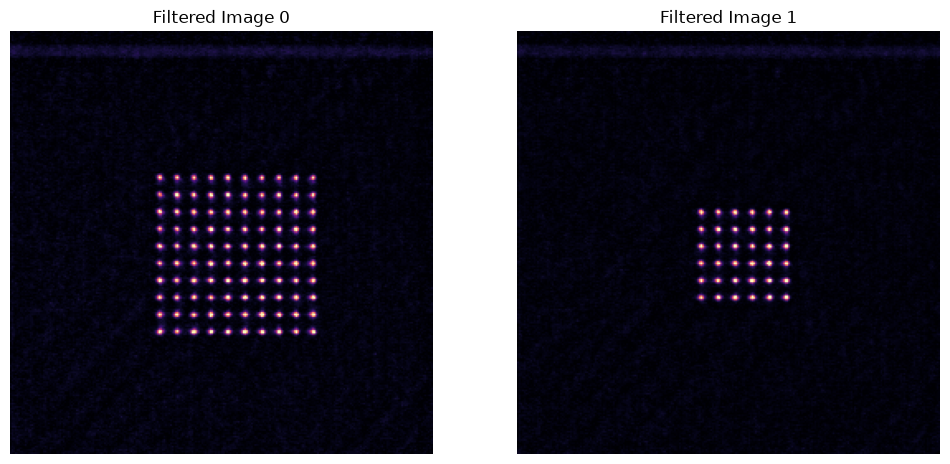

In [21]:
tot_imgs = np.array(imgs_software)

imgs0 = tot_imgs[:, 0, :, :]
imgs1 = tot_imgs[:, 1, :, :]

imgs0_mean = imgs0.mean(axis=0)
imgs1_mean = imgs1.mean(axis=0)

imgs0_mean_filtered = an.morphological_tophat_high_pass(imgs0_mean, feature_size=feature_size)
imgs1_mean_filtered = an.morphological_tophat_high_pass(imgs1_mean, feature_size=feature_size)

# Plot imgs0_mean_filtered and imgs1_mean_filtered side by side
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(imgs0_mean_filtered, cmap='magma', vmax=0.6*imgs0_mean_filtered.max())
plt.title('Filtered Image 0')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imgs1_mean_filtered, cmap='magma', vmax=0.6*imgs1_mean_filtered.max())
plt.title('Filtered Image 1')
plt.axis('off')

plt.show()

Looking for trap sites...
10x10 array detected.


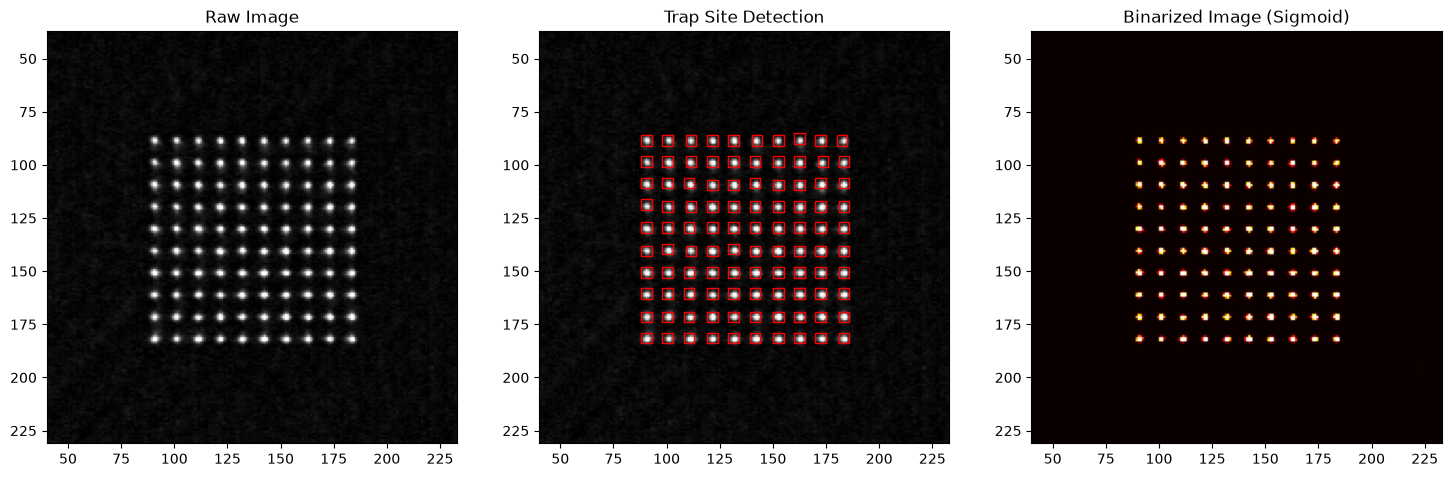

Trap (0, 0) Loading Probability : 54.00 %
Trap (0, 1) Loading Probability : 50.50 %
Trap (0, 2) Loading Probability : 49.00 %
Trap (0, 3) Loading Probability : 57.00 %
Trap (0, 4) Loading Probability : 55.50 %
Trap (0, 5) Loading Probability : 55.00 %
Trap (0, 6) Loading Probability : 52.00 %
Trap (0, 7) Loading Probability : 52.50 %
Trap (0, 8) Loading Probability : 51.50 %
Trap (0, 9) Loading Probability : 53.00 %
Trap (1, 0) Loading Probability : 54.00 %
Trap (1, 1) Loading Probability : 53.50 %
Trap (1, 2) Loading Probability : 51.00 %
Trap (1, 3) Loading Probability : 53.00 %
Trap (1, 4) Loading Probability : 55.00 %
Trap (1, 5) Loading Probability : 55.50 %
Trap (1, 6) Loading Probability : 48.50 %
Trap (1, 7) Loading Probability : 51.50 %
Trap (1, 8) Loading Probability : 47.00 %
Trap (1, 9) Loading Probability : 47.00 %
Trap (2, 0) Loading Probability : 56.50 %
Trap (2, 1) Loading Probability : 59.50 %
Trap (2, 2) Loading Probability : 53.50 %
Trap (2, 3) Loading Probability : 

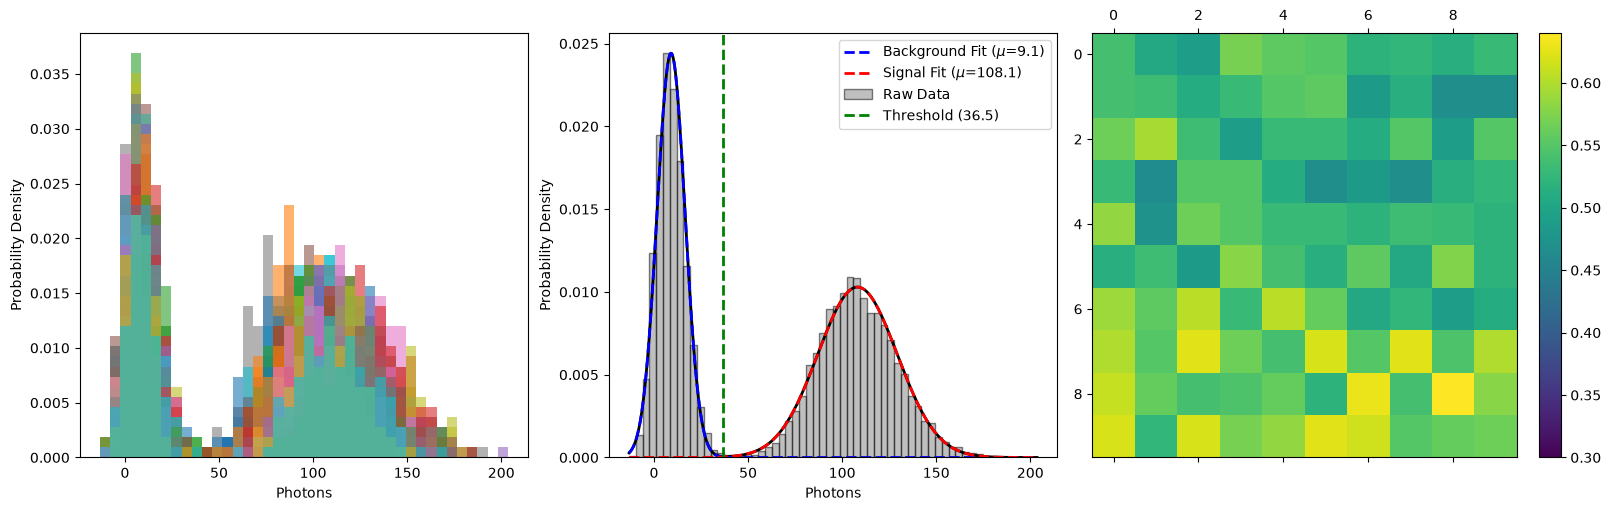

In [22]:
array_shape_1 = [10, 10]
window = 5
feature_size = 10

grid_positions_1, detection_threshold = an.detect_trap_sites(imgs0_mean_filtered, array_shape_1, detection_step=200)
an.visualize_results(imgs0_mean_filtered, grid_positions_1, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs0]
photon_rates, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_1, array_shape_1, threshold_detection=True, window_size=window, binning=60)

Looking for trap sites...
6x6 array detected.


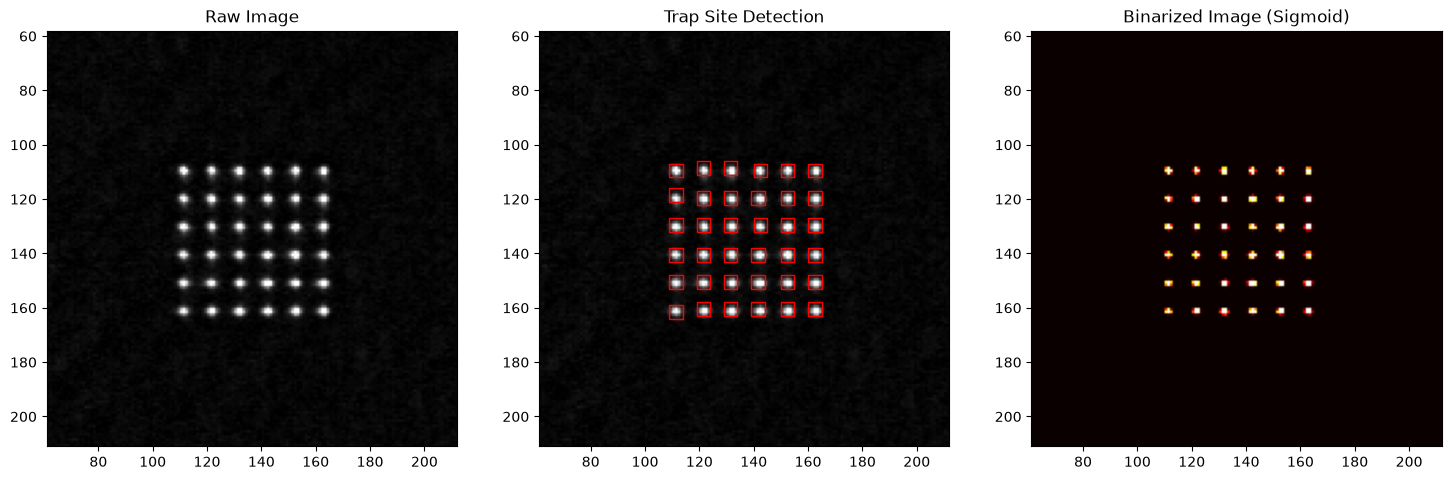

Trap (0, 0) Loading Probability : 94.50 %
Trap (0, 1) Loading Probability : 93.00 %
Trap (0, 2) Loading Probability : 94.00 %
Trap (0, 3) Loading Probability : 91.00 %
Trap (0, 4) Loading Probability : 94.00 %
Trap (0, 5) Loading Probability : 93.00 %
Trap (1, 0) Loading Probability : 97.00 %
Trap (1, 1) Loading Probability : 96.00 %
Trap (1, 2) Loading Probability : 92.50 %
Trap (1, 3) Loading Probability : 89.50 %
Trap (1, 4) Loading Probability : 94.50 %
Trap (1, 5) Loading Probability : 96.50 %
Trap (2, 0) Loading Probability : 93.50 %
Trap (2, 1) Loading Probability : 93.50 %
Trap (2, 2) Loading Probability : 88.50 %
Trap (2, 3) Loading Probability : 89.50 %
Trap (2, 4) Loading Probability : 94.50 %
Trap (2, 5) Loading Probability : 94.00 %
Trap (3, 0) Loading Probability : 94.00 %
Trap (3, 1) Loading Probability : 90.50 %
Trap (3, 2) Loading Probability : 88.00 %
Trap (3, 3) Loading Probability : 93.50 %
Trap (3, 4) Loading Probability : 95.00 %
Trap (3, 5) Loading Probability : 

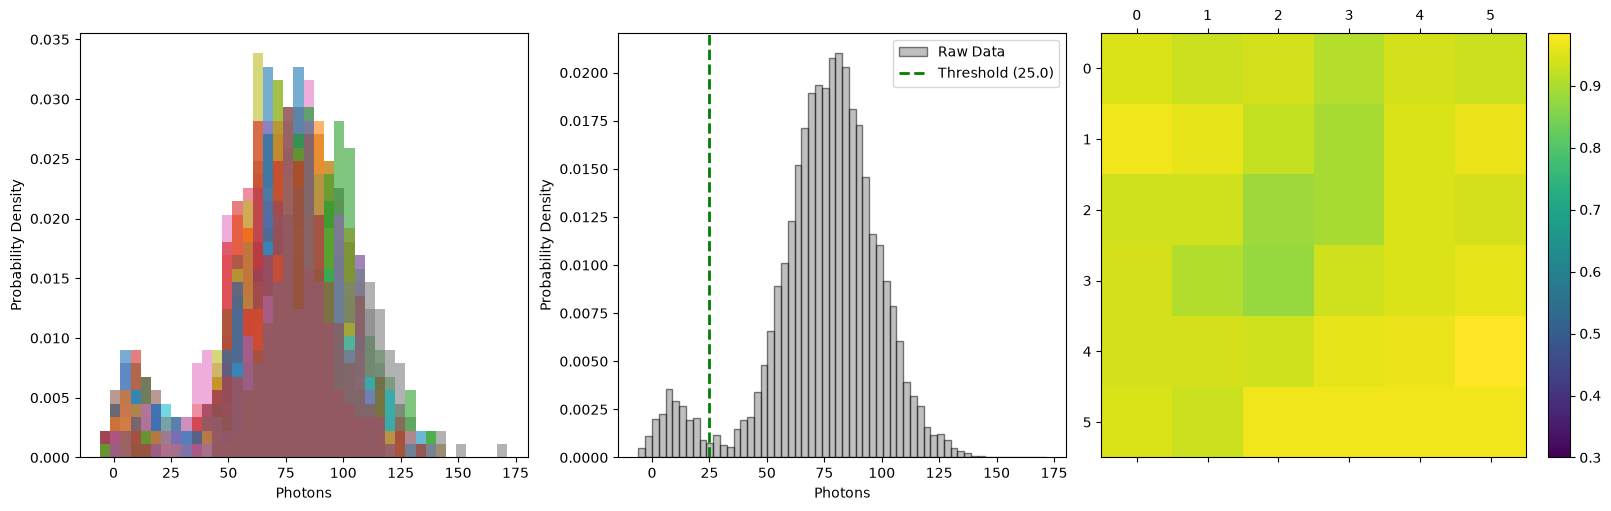

In [25]:
array_shape_2 = [6, 6]
window = 5
feature_size = 10

grid_positions_2, detection_threshold = an.detect_trap_sites(imgs1_mean_filtered, array_shape_2, detection_step=200)
an.visualize_results(imgs1_mean_filtered, grid_positions_2, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photon_rates, loading_probabilities, threshold_2, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_2, array_shape_2, threshold_detection=False, threshold=25, window_size=window, binning=60)

---

### Preflight checks
Offline verification of the rearrangement path — no MOT shot, no trigger, no atoms.
Run this after `initialise` and before either Option A or Option B.

It exercises occupancy extraction end to end on a synthetic frame, which is where
every failure in this pipeline has surfaced so far: stale code in the kernel, a frame
dtype the compiled extension rejects, and ROI/grid mismatches. All of those raise
*inside* `arm_rearrangement`, i.e. only after a shot has already been fired.

In [17]:
import time
import pytweezer.coordinators.rearrangement as rr

problems, notes = [], []

# 1. Which occupancy implementation is actually live? The compiled path is opt-in
#    via USE_SUM_CPP and falls back silently if the extension fails to import, so
#    the only way to know what will run is to ask.
_morph, _summer = rr._morph_cpp(), rr._sum_cpp()
notes.append(f"USE_SUM_CPP={rr.USE_SUM_CPP}  ->  tophat={'C++' if _morph else 'numpy'}, "
             f"pixel-sum={'C++' if _summer else 'numpy'}")

# 2. Is the code in memory current? Editing rearrangement.py does not affect a
#    running kernel, and importlib.reload cannot rebind methods already attached to
#    a live coordinator. Fingerprint the bound method rather than trusting mtimes.
_names = type(coordinator)._extract_occupancy.__code__.co_names
if "Morphological_top_hat_cpp" in _names:
    problems.append("stale _extract_occupancy in memory (pre-fix version) — restart the kernel")

# 3. Coordinator state, and does the grid agree with the array and the ROI?
if not coordinator._initialised:
    problems.append("coordinator.initialise() has not been run")
else:
    _shape = coordinator._state["terms1"][4]
    _n_sites = int(np.prod(_shape))
    if len(grid_positions_1) != _n_sites:
        problems.append(f"grid_positions_1 has {len(grid_positions_1)} sites but terms1 array_shape "
                        f"{list(_shape)} implies {_n_sites}")
    _ys = [y for (y, x) in grid_positions_1.values()]
    _xs = [x for (y, x) in grid_positions_1.values()]
    if max(_ys) >= HEIGHT or max(_xs) >= WIDTH:
        problems.append(f"grid_positions_1 run to (y={max(_ys)}, x={max(_xs)}) but the ROI is "
                        f"{WIDTH}x{HEIGHT} — were the sites detected on a full frame?")
    else:
        notes.append(f"grid: {len(grid_positions_1)} sites, max (y,x)=({max(_ys)},{max(_xs)}), "
                     f"inside the {WIDTH}x{HEIGHT} ROI")
    if not np.isfinite(threshold_counts) or threshold_counts <= 0:
        problems.append(f"threshold_counts is {threshold_counts}")
    else:
        notes.append(f"threshold_counts = {threshold_counts:.1f}")

# 4. What does the camera actually hand back? A frame that is not native '<u2'
#    either skips the compiled path or gets rejected by it at the pybind boundary.
try:
    _frame = np.asarray(imgs1[0])
    notes.append(f"camera frame: {type(imgs1[0]).__name__}, dtype={_frame.dtype.str}, "
                 f"shape={_frame.shape}")
    if _frame.dtype != np.uint16:
        notes.append("   ^ not native uint16 — the compiled occupancy path will be skipped")
    if _frame.shape != (HEIGHT, WIDTH):
        problems.append(f"frame shape {_frame.shape} != ROI ({HEIGHT}, {WIDTH})")
except NameError:
    notes.append("no frames captured yet — run the baseline scan to check the frame dtype")

# 5. Dry-run occupancy extraction on a synthetic ROI-sized uint16 frame with every
#    site lit. A zero threshold means all sites must come back occupied; anything
#    else points at the grid, not the extraction.
if coordinator._initialised:
    try:
        _probe = np.zeros((HEIGHT, WIDTH), dtype=np.uint16)
        for (_i, _j), (_y, _x) in grid_positions_1.items():
            _probe[max(_y - 2, 0):_y + 3, max(_x - 2, 0):_x + 3] = 1000
        _t0 = time.perf_counter()
        _mask = coordinator._extract_occupancy(_probe, coordinator._state["terms1"][4], 0)
        _dt = (time.perf_counter() - _t0) * 1e3
        notes.append(f"occupancy dry-run: {int(_mask.sum())}/{_mask.size} sites over a zero "
                     f"threshold in {_dt:.2f} ms")
        if int(_mask.sum()) != _mask.size:
            problems.append(f"dry-run lit every site but only {int(_mask.sum())}/{_mask.size} came "
                            f"back occupied — grid_positions_1 and the array shape disagree")
    except Exception as _exc:
        problems.append(f"occupancy dry-run failed: {type(_exc).__name__}: {_exc}")

# 6. Does the precomputed initial mask match the panel?
try:
    _dims = slm.get_dimensions()
    notes.append(f"SLM {_dims['width']}x{_dims['height']} @ {_dims['depth']}-bit")
    if coordinator._initialised:
        _init = coordinator._state["pm_init_uint8"]
        if _init.shape != (_dims["height"], _dims["width"]):
            problems.append(f"init mask {_init.shape} != panel "
                            f"({_dims['height']}, {_dims['width']})")
except Exception as _exc:
    notes.append(f"SLM dimensions unavailable: {_exc}")

print("\n".join("  - " + n for n in notes))
if problems:
    print("\nPREFLIGHT FAILED — do not fire a shot:")
    print("\n".join("  ! " + p for p in problems))
else:
    print("\nPREFLIGHT OK — safe to run Option A or Option B")

  - USE_SUM_CPP=False  ->  tophat=numpy, pixel-sum=numpy
  - grid: 100 sites, max (y,x)=(183,182), inside the 256x256 ROI
  - threshold_counts = 5305.1
  - camera frame: ndarray, dtype=<u2, shape=(256, 256)
  - occupancy dry-run: 100/100 sites over a zero threshold in 1.88 ms
  - SLM 1024x1024 @ 8-bit

PREFLIGHT OK — safe to run Option A or Option B


### Option A — fast software pipeline
Per-frame `update_mask` writes, pipelined so GPU generation of frame *n+1* overlaps
the upload of frame *n*. No hardware trigger needed.

In [54]:
import asyncio
from pytweezer.coordinators.rearrangement import Rearrangement
from pytweezer.drivers.arduino import ArduinoPulser

coordinator = Rearrangement({"camera": hamcam, "slm": slm}, {})

data1, array_shape1 = np.stack(terms1[:4]), terms1[4]
data2, array_shape2 = np.stack(terms2[:4]), terms2[4]
await asyncio.to_thread(
    coordinator.initialise,
    data1, data2, array_shape1, array_shape2,
    d0=1.0, fps=1/(1e-6), threshold=threshold_counts,
    grid_positions=grid_positions_1, roi=[X0, Y0, WIDTH, HEIGHT], profile="linear"
)

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um
Phasemask generator initialised.
Camera configured for rearrangement (roi=%s). [110, 220, 256, 256]
Rearrangement node initialised.


In [55]:
# Experiment and camera setup
n_iterations = 1
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)

{'ok': True,
 'command': 'interface_method',
 'method': 'set_run_until_stopped',
 'state': 'accepted'}

In [56]:
N_iterations = 5  # adjust before running
imgs_software = []
err_indices = []
timings_software = []   # kept separate from Option B so the two can be compared

for it in range(N_iterations):
    print(f"Running experiment iteration {it+1} / {N_iterations}")
    rearrangement_task = asyncio.create_task(asyncio.to_thread(coordinator.arm_rearrangement))

    time.sleep(0.1)
    exp.start_motmaster_experiment({
                "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
                "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
                "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
                "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
                "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
                "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
                "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
                "BackgroundDrop": 0})
    img0, img1, timings = await rearrangement_task
    print("Images acquired from rearrangement node.")

    if img1.sum() == 0:
        print(f"Empty image received at iteration {it+1}. Discarding...")
        err_indices.append(it)
    else:
        imgs_software.append([img0, img1])
    timings_software.append(timings)

print(f"Average total rearrangement time = {np.mean([t['total_rearrangement_s'] for t in timings_software])*1000:.2f} ms")

Running experiment iteration 1 / 5
Rearrangement complete: 0 frames, 0.0440s total (occupancy 0.0010s, sequence+upload 0.0030s, reset 0.0400s).
Images acquired from rearrangement node.
Running experiment iteration 2 / 5


RuntimeError: SLM ImageWriteComplete failed

### Option B — preload + hardware trigger
Preloads the whole sequence into the SLM's on-board memory (still pipelined against
GPU generation), then clocks it out with an external trigger — no per-frame software
write on the hot path. Uses the `linear` delivery profile (fewer frames than
`minimum_jerk` for the same `d0`) since it pairs naturally with the trigger path.
Requires the trigger pulser wired to the SLM's external trigger input and a
1024x1024 board on firmware >= 2.4.

In [18]:
arduino = ArduinoPulser('COM5')
startup_message = arduino.connect()
print(f"Arduino connected: {startup_message}")

Arduino connected: Listening for Python...


In [19]:
# Option B preflight — board capability and pulser, before any shot.
# Set True to physically exercise preload + trigger. It preloads the *initial* mask
# into two frame slots and clocks one pulse, so the panel shows what it already
# shows — but it does drive the board, so leave it off during a running sequence.
RUN_TRIGGER_DRYRUN = False

b_problems, b_notes = [], []

# start_auto_increment is 1024x1024 / firmware >= 2.4 only. The firmware revision
# is not exposed by the driver, so geometry is as far as this check can go — a
# 2.3 board passes here and fails at start_auto_increment().
try:
    _dims = slm.get_dimensions()
    if (_dims["width"], _dims["height"]) != (1024, 1024):
        b_problems.append(f"preload+trigger needs a 1024x1024 board; this is "
                          f"{_dims['width']}x{_dims['height']}")
    else:
        b_notes.append(f"SLM {_dims['width']}x{_dims['height']} (firmware rev not queryable — "
                       f"if start_auto_increment fails, suspect firmware < 2.4)")
    for _m in ("preload_image", "set_wait_for_trigger", "start_auto_increment",
               "stop_auto_increment"):
        if not hasattr(slm, _m):
            b_problems.append(f"SLM driver has no {_m}()")
except Exception as _exc:
    b_problems.append(f"could not query the SLM: {_exc}")

# Pulser
if "arduino" not in dir() or arduino is None:
    b_problems.append("arduino pulser not created — run the ArduinoPulser cell above")
elif not hasattr(arduino, "send_pulses"):
    b_problems.append(f"{type(arduino).__name__} has no send_pulses(n, period_us=...)")
else:
    b_notes.append(f"pulser {type(arduino).__name__} ready")

if RUN_TRIGGER_DRYRUN and not b_problems:
    try:
        _mask0 = coordinator._state["pm_init_uint8"]
        slm.set_wait_for_trigger(False)          # must be off while preloading
        for _k in range(2):
            slm.preload_image(_mask0, _k)
        slm.set_wait_for_trigger(True)
        slm.start_auto_increment(2)
        try:
            arduino.send_pulses(1, period_us=700)
        finally:
            slm.stop_auto_increment()
            slm.set_wait_for_trigger(False)
        b_notes.append("trigger dry-run OK: 2 frames preloaded, 1 pulse clocked")
    except Exception as _exc:
        b_problems.append(f"trigger dry-run failed: {type(_exc).__name__}: {_exc}")

print("\n".join("  - " + n for n in b_notes))
if b_problems:
    print("\nOPTION B PREFLIGHT FAILED:")
    print("\n".join("  ! " + p for p in b_problems))
else:
    print("\nOPTION B PREFLIGHT OK" + ("" if RUN_TRIGGER_DRYRUN else
          " (set RUN_TRIGGER_DRYRUN = True to actually exercise the trigger path)"))

  - SLM 1024x1024 (firmware rev not queryable — if start_auto_increment fails, suspect firmware < 2.4)
  - pulser ArduinoPulser ready

OPTION B PREFLIGHT OK (set RUN_TRIGGER_DRYRUN = True to actually exercise the trigger path)


In [20]:
# Experiment and camera setup
n_iterations = 1
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)

{'ok': True,
 'command': 'interface_method',
 'method': 'set_run_until_stopped',
 'state': 'accepted'}

In [ ]:
N_iterations = 50  # adjust before running
imgs_trigger = []
err_indices = []
timings_trigger = []   # kept separate from Option A so the two can be compared

for it in range(N_iterations):
    print(f"Running experiment iteration {it+1} / {N_iterations}")
    rearrangement_task = asyncio.create_task(asyncio.to_thread(
        coordinator.arm_rearrangement_preload_trigger, arduino, period_us=700, profile="linear", restore_initial_array=True
    ))

    time.sleep(0.1)
    exp.start_motmaster_experiment({
                "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
                "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
                "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
                "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
                "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
                "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
                "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
                "BackgroundDrop": 0})
    img0, img1, timings = await rearrangement_task
    print("Images acquired from rearrangement node.")

    if img1.sum() == 0:
        print(f"Empty image received at iteration {it+1}. Discarding...")
        err_indices.append(it)
    else:
        imgs_trigger.append([img0, img1])
    timings_trigger.append(timings)

print(f"Average total rearrangement time = {np.mean([t['total_rearrangement_s'] for t in timings_trigger])*1000:.2f} ms")

Running experiment iteration 1 / 50


2026-08-10 19:19:42 | INFO     | PH-BEAST | pytweezer.drivers.slm | Wait-for-trigger disabled.
2026-08-10 19:19:42 | INFO     | PH-BEAST | pytweezer.drivers.slm | Wait-for-trigger enabled.
2026-08-10 19:19:42 | INFO     | PH-BEAST | pytweezer.drivers.slm | Auto-increment armed over 12 frames.
2026-08-10 19:19:42 | INFO     | PH-BEAST | pytweezer.drivers.slm | Auto-increment stopped.
2026-08-10 19:19:42 | INFO     | PH-BEAST | pytweezer.drivers.slm | Wait-for-trigger disabled.


Rearrangement (preload+trigger) complete: %d frames, %.4fs total (occupancy %.4fs, preload %.4fs, trigger playback %.4fs, reset %.4fs). 12 0.04438519477844238 0.0009989738464355469 0.009001016616821289 0.012385129928588867 0.02200007438659668
Images acquired from rearrangement node.
Running experiment iteration 2 / 50


2026-08-10 19:19:42 | INFO     | PH-BEAST | pytweezer.drivers.slm | Wait-for-trigger disabled.
2026-08-10 19:19:42 | INFO     | PH-BEAST | pytweezer.drivers.slm | Wait-for-trigger enabled.
2026-08-10 19:19:42 | INFO     | PH-BEAST | pytweezer.drivers.slm | Auto-increment armed over 8 frames.
2026-08-10 19:19:42 | INFO     | PH-BEAST | pytweezer.drivers.slm | Auto-increment stopped.
2026-08-10 19:19:42 | INFO     | PH-BEAST | pytweezer.drivers.slm | Wait-for-trigger disabled.


Rearrangement (preload+trigger) complete: %d frames, %.4fs total (occupancy %.4fs, preload %.4fs, trigger playback %.4fs, reset %.4fs). 8 0.04500007629394531 0.0019996166229248047 0.007000446319580078 0.00899958610534668 0.02700042724609375
Images acquired from rearrangement node.
Running experiment iteration 3 / 50


2026-08-10 19:19:43 | INFO     | PH-BEAST | pytweezer.drivers.slm | Wait-for-trigger disabled.
2026-08-10 19:19:43 | INFO     | PH-BEAST | pytweezer.drivers.slm | Wait-for-trigger enabled.
2026-08-10 19:19:43 | INFO     | PH-BEAST | pytweezer.drivers.slm | Auto-increment armed over 10 frames.
2026-08-10 19:19:43 | INFO     | PH-BEAST | pytweezer.drivers.slm | Auto-increment stopped.
2026-08-10 19:19:43 | INFO     | PH-BEAST | pytweezer.drivers.slm | Wait-for-trigger disabled.


Rearrangement (preload+trigger) complete: %d frames, %.4fs total (occupancy %.4fs, preload %.4fs, trigger playback %.4fs, reset %.4fs). 10 0.045000314712524414 0.001999378204345703 0.008000612258911133 0.009999752044677734 0.025000572204589844
Images acquired from rearrangement node.
Running experiment iteration 4 / 50


2026-08-10 19:19:44 | INFO     | PH-BEAST | pytweezer.drivers.slm | Wait-for-trigger disabled.
2026-08-10 19:19:44 | INFO     | PH-BEAST | pytweezer.drivers.slm | Wait-for-trigger enabled.
2026-08-10 19:19:44 | INFO     | PH-BEAST | pytweezer.drivers.slm | Auto-increment armed over 0 frames.
2026-08-10 19:19:44 | INFO     | PH-BEAST | pytweezer.drivers.slm | Auto-increment stopped.
2026-08-10 19:19:44 | INFO     | PH-BEAST | pytweezer.drivers.slm | Wait-for-trigger disabled.


RuntimeError: Arduino rejected '-1,700': ERR bad count

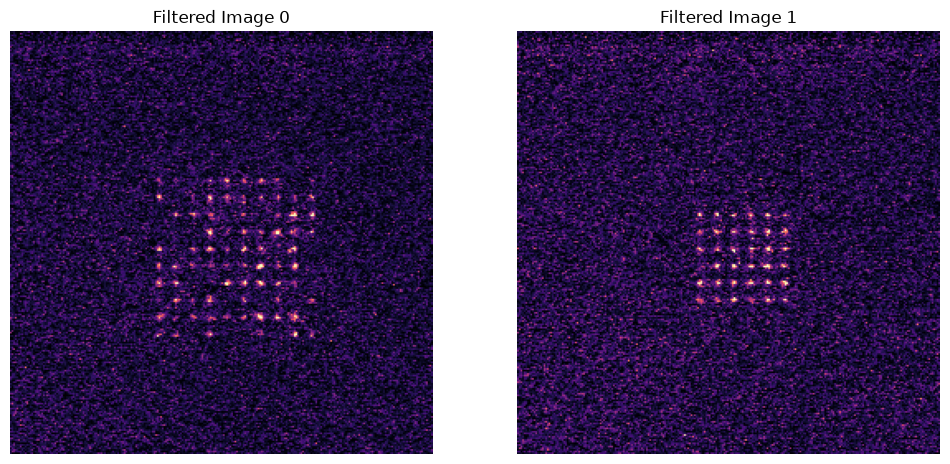

In [24]:
tot_imgs = np.array(imgs_trigger)

imgs0 = tot_imgs[:, 0, :, :]
imgs1 = tot_imgs[:, 1, :, :]

imgs0_mean = imgs0.mean(axis=0)
imgs1_mean = imgs1.mean(axis=0)

imgs0_mean_filtered = an.morphological_tophat_high_pass(imgs0_mean, feature_size=feature_size)
imgs1_mean_filtered = an.morphological_tophat_high_pass(imgs1_mean, feature_size=feature_size)

# Plot imgs0_mean_filtered and imgs1_mean_filtered side by side
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(imgs0_mean_filtered, cmap='magma', vmax=0.6*imgs0_mean_filtered.max())
plt.title('Filtered Image 0')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imgs1_mean_filtered, cmap='magma', vmax=0.6*imgs1_mean_filtered.max())
plt.title('Filtered Image 1')
plt.axis('off')

plt.show()

### Timing — Option A vs Option B
Both methods return the **same four keys with different meanings**, so the dicts must
not be diffed blindly:

| key | Option A (software pipeline) | Option B (preload + trigger) |
|---|---|---|
| `occupancy_extraction_s` | occupancy extraction | same |
| `rearrangement_sequence_generation_s` | GPU generation **and** upload — one pipelined span | GPU generation + on-board preload |
| `slm_upload_s` | *the same span again*, not a separate measurement | hardware-triggered playback |
| `total_rearrangement_s` | image → sequence → reset image | same, plus the trigger phase |

Option A reports one span under two keys deliberately: generation and upload overlap,
so splitting them would only show where the pipeline happened to stall. Option B's two
phases are genuinely sequential and separately meaningful.

---

In [29]:
hamcam.close()
slm.close()
motcam.close()

ImagEM X2 camera closed.
SLM 1 closed.
Thorlabs TLCamera - motcam - closed.
